In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN
import contextily as ctx
from pointpats import distance_statistics
from sqlalchemy import create_engine

engine = create_engine(
    "postgresql+psycopg2://berdefizita@localhost:5432/twitter_cities_test"
)
from sqlalchemy import text

In [2]:
import contextily as ctx

In [ ]:
with engine.begin() as conn:
    conn.execute(text("drop table if exists mention_network_text;"))
    conn.execute(text(
    """create table mention_network_text as
       select distinct a.*, b.text
       from mention_network a
       left join tweet b on a.tweet_id = b.tweet_id"""
    ))

    conn.execute(text("drop table if exists reply_network_text;"))
    conn.execute(text(
    """create table reply_network_text as
       select distinct a.*, b.text
       from reply_network a
       left join tweet b on a.tweet_id = b.tweet_id"""
    ))

In [2]:
with engine.begin() as conn:

    conn.execute(text("drop table if exists london_home_users;"))
    conn.execute(text("""
        create table london_home_users as
        select distinct user_id
        from homelocation_zi
        where city_bbox = 'london'
          and (homelocation_h3_10 = 'Y' or homelocation_h3_9 = 'Y' or homelocation_h3_8 = 'Y');
    """))

    conn.execute(text("drop table if exists mention_edges;"))
    conn.execute(text("""
        create table mention_edges as
        select distinct
               b.user_id1_source,
               b.user_id2_interaction
        from homelocation_zi a
        inner join mention_network b on a.tweet_id = b.tweet_id
                                    and b.user_id1_source = a.user_id
        inner join london_home_users c on b.user_id1_source = c.user_id
        where a.city_bbox = 'london';
    """))

    conn.execute(text("drop table if exists reply_edges;"))
    conn.execute(text("""
        create table reply_edges as
        select distinct
               b.user_id1_source,
               b.user_id2_interaction
        from homelocation_zi a
        inner join reply_network b on a.tweet_id = b.tweet_id
                                    and b.user_id1_source = a.user_id
        inner join london_home_users c on b.user_id1_source = c.user_id
        where a.city_bbox = 'london';
    """))

In [6]:
mention_edges = pd.read_sql("""
select user_id1_source, user_id2_interaction
from mention_edges
""", engine)

reply_edges = pd.read_sql("""
select user_id1_source, user_id2_interaction
from reply_edges
""", engine)

In [7]:
import networkx as nx

G_mention = nx.from_pandas_edgelist(
    mention_edges,
    source="user_id1_source",
    target="user_id2_interaction",
    create_using=nx.DiGraph()
)

G_reply = nx.from_pandas_edgelist(
    reply_edges,
    source="user_id1_source",
    target="user_id2_interaction",
    create_using=nx.DiGraph()
)

In [8]:
def degree_table(G):
    return pd.DataFrame({
        "user_id": list(G.nodes()),
        "in_degree": [G.in_degree(n) for n in G.nodes()],
        "out_degree": [G.out_degree(n) for n in G.nodes()],
        "total_degree": [G.degree(n) for n in G.nodes()]
    })

In [9]:
mention_degree = degree_table(G_mention)
reply_degree = degree_table(G_reply)

MENTION

In [10]:
mention_degree[["in_degree", "out_degree", "total_degree"]].describe()

,in_degree,out_degree,total_degree
count,1.452998e+06,1.452998e+06,1.452998e+06
mean,2.454105e+00,2.454105e+00,4.908210e+00
std,1.864590e+01,1.731174e+01,2.567422e+01
min,0.000000e+00,0.000000e+00,1.000000e+00
25%,1.000000e+00,0.000000e+00,1.000000e+00
50%,1.000000e+00,0.000000e+00,1.000000e+00
75%,2.000000e+00,0.000000e+00,2.000000e+00
max,8.661000e+03,3.492000e+03,8.661000e+03


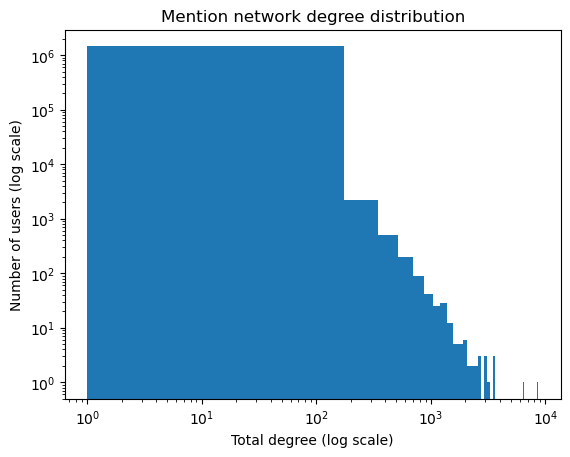

In [12]:
plt.hist(mention_degree["total_degree"], bins=50)
plt.xscale("log")
plt.yscale("log")

plt.xlabel("Total degree (log scale)")
plt.ylabel("Number of users (log scale)")
plt.title("Mention network degree distribution")

plt.show()

In [ ]:
# degree table on the full mention network
mention_degree = pd.DataFrame({
    "user_id": list(G_mention.nodes()),
    "in_degree": [G_mention.in_degree(n) for n in G_mention.nodes()],
    "out_degree": [G_mention.out_degree(n) for n in G_mention.nodes()],
    "total_degree": [G_mention.degree(n) for n in G_mention.nodes()]
})

# percentile-based outlier filtering
# in_q = 0.995 - abszolút szám v ratio
# out_q = 0.995

in_cutoff = mention_degree["in_degree"].quantile(in_q)
out_cutoff = mention_degree["out_degree"].quantile(out_q)

source_keep = set(
    mention_degree.loc[
        mention_degree["out_degree"] <= out_cutoff,
        "user_id"
    ]
)

target_keep = set(
    mention_degree.loc[
        mention_degree["in_degree"] <= in_cutoff,
        "user_id"
    ]
)

mention_edges_filtered = mention_edges[
    mention_edges["user_id1_source"].isin(source_keep) &
    mention_edges["user_id2_interaction"].isin(target_keep)
].copy()

# check filtering effect
filter_summary = pd.DataFrame({
    "network": ["original", "filtered"],
    "edges": [len(mention_edges), len(mention_edges_filtered)],
    "source_users": [
        mention_edges["user_id1_source"].nunique(),
        mention_edges_filtered["user_id1_source"].nunique()
    ],
    "target_users": [
        mention_edges["user_id2_interaction"].nunique(),
        mention_edges_filtered["user_id2_interaction"].nunique()
    ]
})

filter_summary

,network,edges,source_users,target_users
0,original,3565810,158018,1369602
1,filtered,1718091,146121,1004887


Internal London nodes: 90772
Internal London edges: 150410

log-log scatter plot degree distr

In [34]:
# London home users
london_home_users_df = pd.read_sql("""
select distinct user_id
from london_home_users
""", engine)

london_home_user_set = set(london_home_users_df["user_id"])

# keep only edges between London home-location users
mention_edges_london_internal = mention_edges_filtered[
    mention_edges_filtered["user_id1_source"].isin(london_home_user_set) &
    mention_edges_filtered["user_id2_interaction"].isin(london_home_user_set)
].copy()

# remove self-loops
mention_edges_london_internal_noself = mention_edges_london_internal[
    mention_edges_london_internal["user_id1_source"] != 
    mention_edges_london_internal["user_id2_interaction"]
].copy()

# build internal London mention graph
G_mention_internal = nx.from_pandas_edgelist(
    mention_edges_london_internal_noself,
    source="user_id1_source",
    target="user_id2_interaction",
    create_using=nx.DiGraph()
)

# largest weakly connected component
components = sorted(
    nx.weakly_connected_components(G_mention_internal),
    key=len,
    reverse=True
)

largest_component_nodes = components[0]

G_mention_lcc = G_mention_internal.subgraph(largest_component_nodes).copy()

print("Internal London nodes:", G_mention_internal.number_of_nodes())
print("Internal London edges:", G_mention_internal.number_of_edges())
print("Largest component nodes:", G_mention_lcc.number_of_nodes())
print("Largest component edges:", G_mention_lcc.number_of_edges())

Internal London nodes: 90772
Internal London edges: 150410
Largest component nodes: 79304
Largest component edges: 142607


In [35]:
G_mention_lcc_undirected = G_mention_lcc.to_undirected()

print("Self-loops:", nx.number_of_selfloops(G_mention_lcc_undirected))

core_numbers = nx.core_number(G_mention_lcc_undirected)

core_df = pd.DataFrame({
    "user_id": list(core_numbers.keys()),
    "core": list(core_numbers.values())
})

core_df["core"].describe()

Self-loops: 0


count    79304.000000
mean         1.854257
std          0.821507
min          1.000000
25%          1.000000
50%          2.000000
75%          2.000000
max          6.000000
Name: core, dtype: float64

In [36]:
core_df["core"].value_counts().sort_index(ascending=False).head(20)

core
6       14
5       75
4      838
3    18719
2    27424
1    32234
Name: count, dtype: int64

In [ ]:
# select 4-core nodes
k = 4

G_mention_core_undirected = nx.k_core(
    G_mention_lcc.to_undirected(),
    k=k
)

core_nodes = set(G_mention_core_undirected.nodes())

# keep direction from the original directed graph
G_mention_core_directed = G_mention_lcc.subgraph(core_nodes).copy()

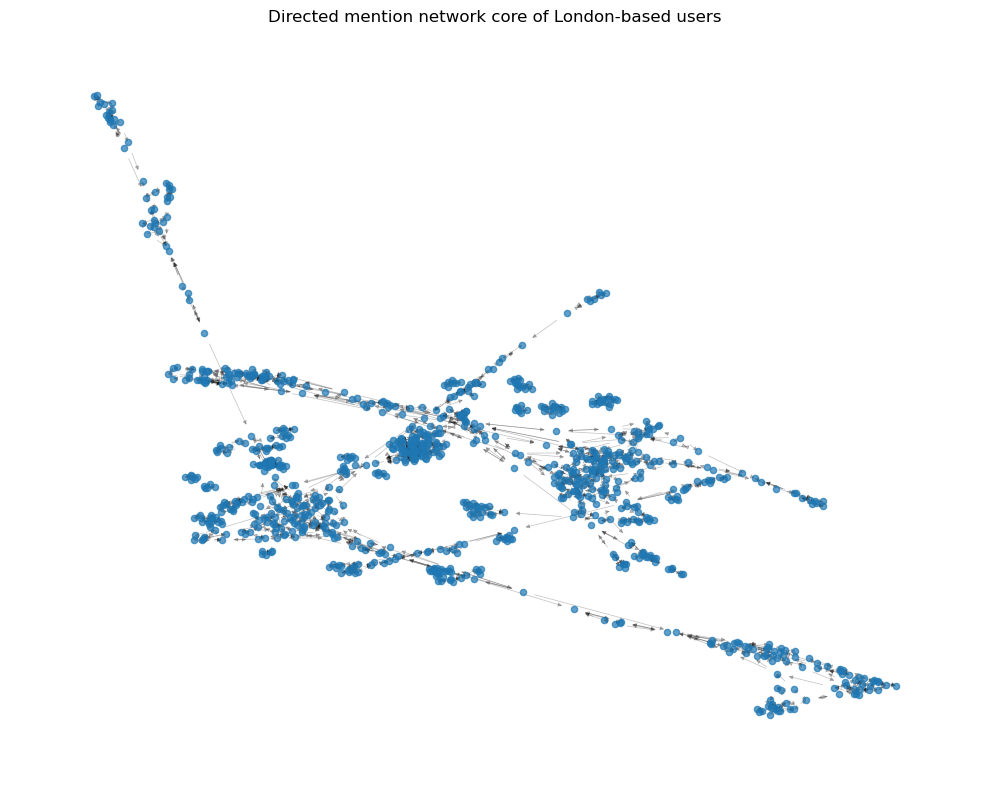

In [42]:
plt.figure(figsize=(10, 8))

pos = nx.spring_layout(
    G_mention_core_directed,
    seed=42,
    iterations=50
)

nx.draw_networkx_nodes(
    G_mention_core_directed,
    pos,
    node_size=20,
    alpha=0.7
)

nx.draw_networkx_edges(
    G_mention_core_directed,
    pos,
    arrows=True,
    arrowsize=6,
    alpha=0.25,
    width=0.5
)

plt.title("Directed mention network core of London-based users")
plt.axis("off")
plt.tight_layout()
plt.show()

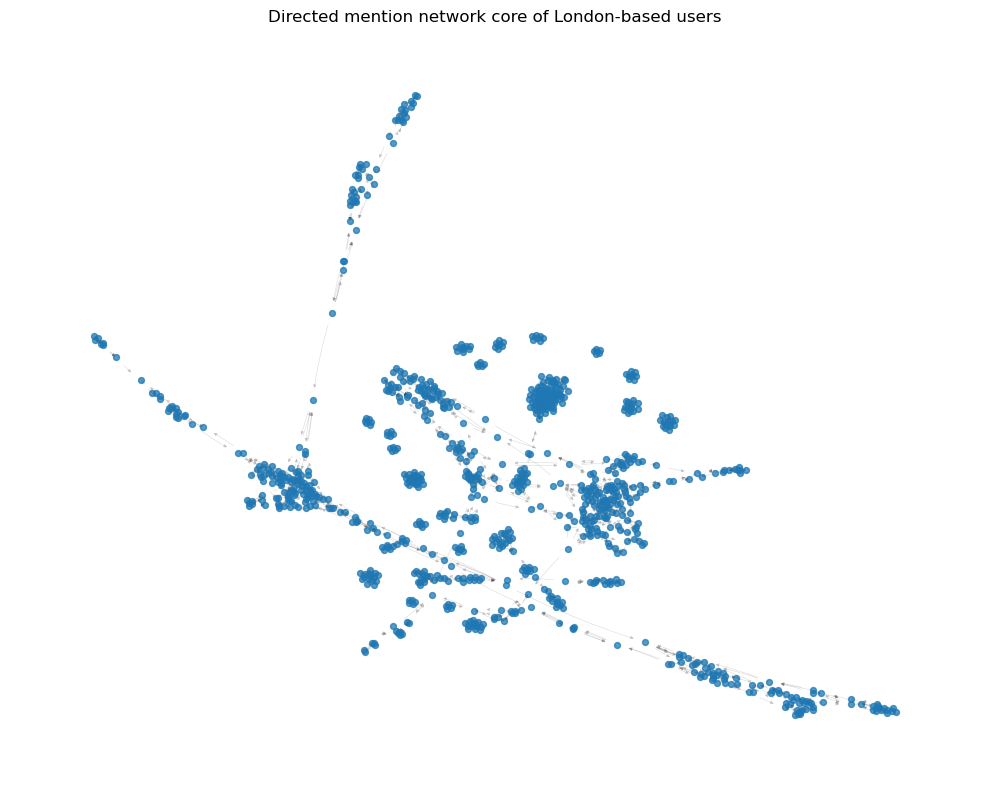

In [43]:
plt.figure(figsize=(10, 8))

pos = nx.spring_layout(
    G_mention_core_directed.to_undirected(),
    seed=42,
    k=0.45,
    iterations=200,
    scale=2
)

nx.draw_networkx_edges(
    G_mention_core_directed,
    pos,
    arrows=True,
    arrowsize=5,
    alpha=0.15,
    width=0.4,
    connectionstyle="arc3,rad=0.05"
)

nx.draw_networkx_nodes(
    G_mention_core_directed,
    pos,
    node_size=18,
    alpha=0.75
)

plt.title("Directed mention network core of London-based users")
plt.axis("off")
plt.tight_layout()
plt.show()

In [44]:
import geopandas as gpd
from shapely.geometry import Point, LineString

In [46]:
home_coords = pd.read_sql("""
select distinct on (user_id)
       user_id,
       h3_10,
       lon,
       lat
from homelocation_zi
where city_bbox = 'london'
and homelocation_h3_10 = 'Y'
order by user_id, tweet_id
""", engine)

In [67]:
# nodes from the directed mention core
mention_core_nodes = pd.DataFrame({
    "user_id": list(G_mention_core_directed.nodes())
})

mention_core_nodes = mention_core_nodes.merge(
    home_coords,
    on="user_id",
    how="inner"
)

mention_node_gdf = gpd.GeoDataFrame(
    mention_core_nodes,
    geometry=gpd.points_from_xy(
        mention_core_nodes["lon"],
        mention_core_nodes["lat"]
    ),
    crs="EPSG:4326"
)

# edges from the directed mention core
mention_core_edges = nx.to_pandas_edgelist(
    G_mention_core_directed
).rename(columns={
    "source": "source_user",
    "target": "target_user"
})

mention_core_edges_geo = (
    mention_core_edges
    .merge(
        home_coords.rename(columns={
            "user_id": "source_user",
            "lon": "source_lon",
            "lat": "source_lat"
        }),
        on="source_user",
        how="inner"
    )
    .merge(
        home_coords.rename(columns={
            "user_id": "target_user",
            "lon": "target_lon",
            "lat": "target_lat"
        }),
        on="target_user",
        how="inner"
    )
)

mention_edge_gdf = gpd.GeoDataFrame(
    mention_core_edges_geo,
    geometry=[
        LineString([
            (row.source_lon, row.source_lat),
            (row.target_lon, row.target_lat)
        ])
        for row in mention_core_edges_geo.itertuples()
    ],
    crs="EPSG:4326"
)

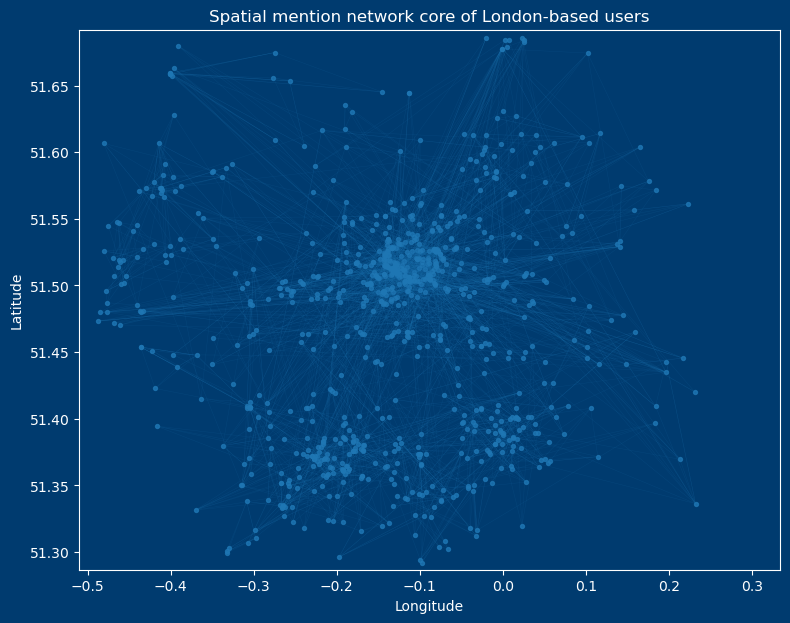

In [51]:
fig, ax = plt.subplots(figsize=(8, 8))

fig.patch.set_facecolor("#003b6f")
ax.set_facecolor("#003b6f")

# edges
mention_edge_gdf.plot(
    ax=ax,
    linewidth=0.4,
    alpha=0.15
)

# nodes
mention_node_gdf.plot(
    ax=ax,
    markersize=8,
    alpha=0.8
)

ax.set_xlim(-0.5103751, 0.3340155)
ax.set_ylim(51.2867601, 51.6918741)

ax.set_title(
    "Spatial mention network core of London-based users",
    color="white"
)

ax.set_xlabel("Longitude", color="white")
ax.set_ylabel("Latitude", color="white")

ax.tick_params(axis="x", colors="white")
ax.tick_params(axis="y", colors="white")

for spine in ax.spines.values():
    spine.set_color("white")

plt.tight_layout()
plt.show()

In [69]:
from shapely.geometry import box

Spatial mention network core of London-based users:

* the map shows the internal mention network of users with inferred London home location
* nodes represent users, positioned by one observed tweet coordinate from their inferred H3-10 home hexagon
* edges represent mention relations between London home-location users
* only edges where both the source and target users have London home location are shown
* the displayed network is the 4-core of the largest connected component, so it focuses on the structurally more connected part of the London user network
* lines indicate network connections, not physical movement or travel routes
* the map shows that the mention network is geographically spread across Greater London, with a denser concentration around central London

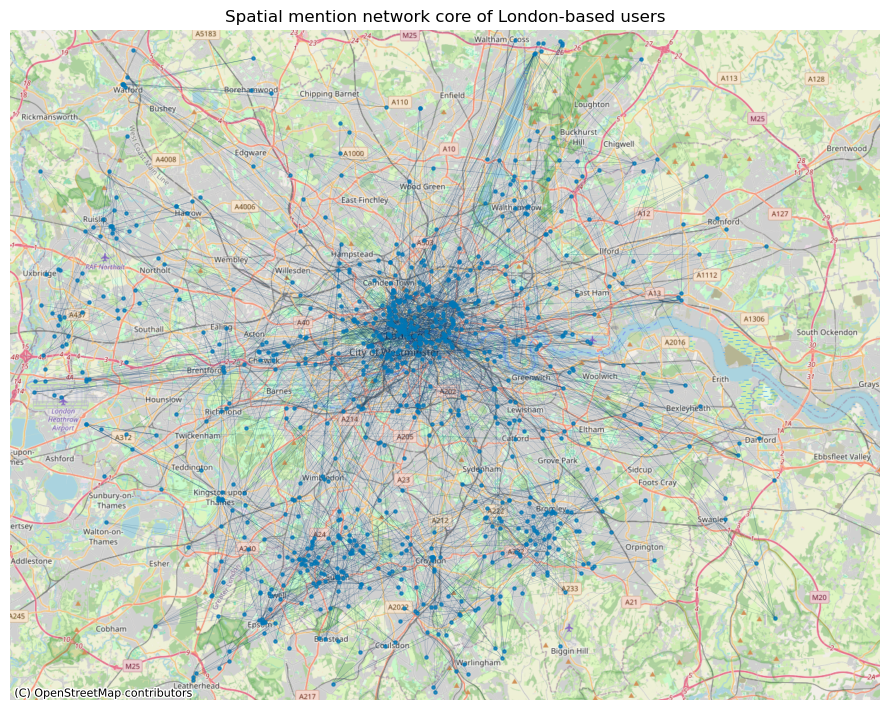

In [ ]:
mention_node_gdf_3857 = mention_node_gdf.to_crs(epsg=3857)
mention_edge_gdf_3857 = mention_edge_gdf.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(9, 9))

london_bbox = gpd.GeoDataFrame(
    geometry=[box(-0.5103751, 51.2867601, 0.3340155, 51.6918741)],
    crs="EPSG:4326"
).to_crs(epsg=3857)

xmin, ymin, xmax, ymax = london_bbox.total_bounds
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

ctx.add_basemap(
    ax,
    source=ctx.providers.OpenStreetMap.Mapnik,
    zoom=11
)

mention_edge_gdf_3857.plot(
    ax=ax,
    linewidth=0.35,
    alpha=0.18,
    color="#003b6f",
    zorder=2
)

mention_node_gdf_3857.plot(
    ax=ax,
    markersize=5,
    alpha=0.75,
    color="#0077b6",
    zorder=3
)

ax.set_title("Spatial mention network core of London-based users")
ax.set_axis_off()

plt.tight_layout()
plt.show()

REPLY

In [13]:
reply_degree[["in_degree", "out_degree", "total_degree"]].describe()

,in_degree,out_degree,total_degree
count,1.768774e+06,1.768774e+06,1.768774e+06
mean,2.196481e+00,2.196481e+00,4.392961e+00
std,1.032570e+01,2.071242e+01,2.362193e+01
min,0.000000e+00,0.000000e+00,1.000000e+00
25%,1.000000e+00,0.000000e+00,1.000000e+00
50%,1.000000e+00,0.000000e+00,1.000000e+00
75%,2.000000e+00,0.000000e+00,2.000000e+00
max,3.294000e+03,4.699000e+03,4.761000e+03


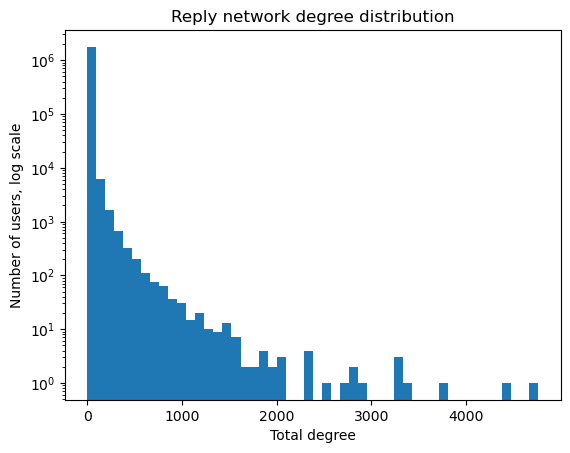

In [12]:
plt.hist(reply_degree["total_degree"], bins=50)
plt.yscale("log")
plt.xlabel("Total degree")
plt.ylabel("Number of users, log scale")
plt.title("Reply network degree distribution")
plt.show()

In [75]:
# degree table on the full reply network
reply_degree = pd.DataFrame({
    "user_id": list(G_reply.nodes()),
    "in_degree": [G_reply.in_degree(n) for n in G_reply.nodes()],
    "out_degree": [G_reply.out_degree(n) for n in G_reply.nodes()],
    "total_degree": [G_reply.degree(n) for n in G_reply.nodes()]
})

reply_in_q = 0.995
reply_out_q = 0.995

reply_in_cutoff = reply_degree["in_degree"].quantile(reply_in_q)
reply_out_cutoff = reply_degree["out_degree"].quantile(reply_out_q)

reply_source_keep = set(
    reply_degree.loc[
        reply_degree["out_degree"] <= reply_out_cutoff,
        "user_id"
    ]
)

reply_target_keep = set(
    reply_degree.loc[
        reply_degree["in_degree"] <= reply_in_cutoff,
        "user_id"
    ]
)

reply_edges_filtered = reply_edges[
    reply_edges["user_id1_source"].isin(reply_source_keep) &
    reply_edges["user_id2_interaction"].isin(reply_target_keep)
].copy()

reply_filter_summary = pd.DataFrame({
    "network": ["original", "filtered"],
    "edges": [len(reply_edges), len(reply_edges_filtered)],
    "source_users": [
        reply_edges["user_id1_source"].nunique(),
        reply_edges_filtered["user_id1_source"].nunique()
    ],
    "target_users": [
        reply_edges["user_id2_interaction"].nunique(),
        reply_edges_filtered["user_id2_interaction"].nunique()
    ]
})

reply_filter_summary

,network,edges,source_users,target_users
0,original,3885078,140999,1718916
1,filtered,1804458,130303,1145933


In [76]:
# London home users
reply_london_home_users_df = pd.read_sql("""
select distinct user_id
from london_home_users
""", engine)

reply_london_home_user_set = set(reply_london_home_users_df["user_id"])

# keep only reply edges between London home-location users
reply_edges_london_internal = reply_edges_filtered[
    reply_edges_filtered["user_id1_source"].isin(reply_london_home_user_set) &
    reply_edges_filtered["user_id2_interaction"].isin(reply_london_home_user_set)
].copy()

# remove self-loops
reply_edges_london_internal_noself = reply_edges_london_internal[
    reply_edges_london_internal["user_id1_source"] != 
    reply_edges_london_internal["user_id2_interaction"]
].copy()

# build internal London reply graph
G_reply_internal = nx.from_pandas_edgelist(
    reply_edges_london_internal_noself,
    source="user_id1_source",
    target="user_id2_interaction",
    create_using=nx.DiGraph()
)

# largest weakly connected component
reply_components = sorted(
    nx.weakly_connected_components(G_reply_internal),
    key=len,
    reverse=True
)

reply_largest_component_nodes = reply_components[0]

G_reply_lcc = G_reply_internal.subgraph(reply_largest_component_nodes).copy()

print("Internal London reply nodes:", G_reply_internal.number_of_nodes())
print("Internal London reply edges:", G_reply_internal.number_of_edges())
print("Largest reply component nodes:", G_reply_lcc.number_of_nodes())
print("Largest reply component edges:", G_reply_lcc.number_of_edges())

Internal London reply nodes: 91961
Internal London reply edges: 155605
Largest reply component nodes: 80829
Largest reply component edges: 147931


In [77]:
G_reply_lcc_undirected = G_reply_lcc.to_undirected()

print("Self-loops:", nx.number_of_selfloops(G_reply_lcc_undirected))

reply_core_numbers = nx.core_number(G_reply_lcc_undirected)

reply_core_df = pd.DataFrame({
    "user_id": list(reply_core_numbers.keys()),
    "core": list(reply_core_numbers.values())
})

reply_core_df["core"].describe()

Self-loops: 0


count    80829.000000
mean         1.895273
std          0.816278
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max          7.000000
Name: core, dtype: float64

In [78]:
reply_core_df["core"].value_counts().sort_index(ascending=False).head(20)

core
7       13
6        4
5        7
4      606
3    21044
2    28332
1    30823
Name: count, dtype: int64

In [79]:
# select 4-core nodes
reply_k = 4

G_reply_core_undirected = nx.k_core(
    G_reply_lcc.to_undirected(),
    k=reply_k
)

reply_core_nodes = set(G_reply_core_undirected.nodes())

# keep direction from the original directed graph
G_reply_core_directed = G_reply_lcc.subgraph(reply_core_nodes).copy()

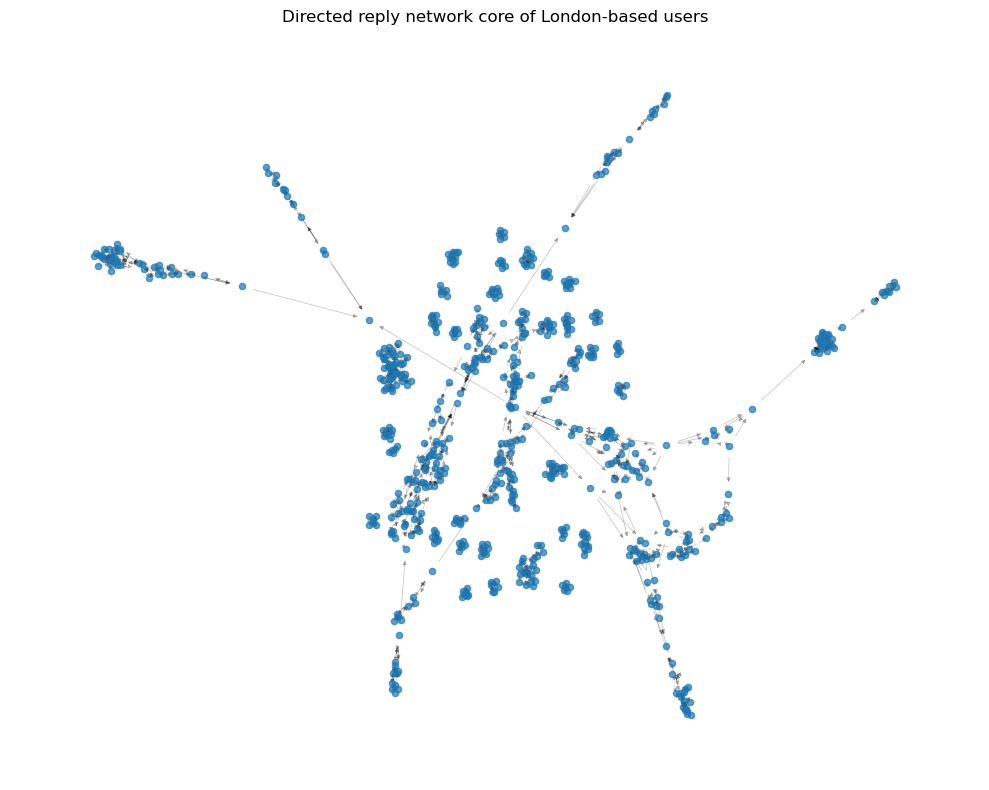

In [80]:
plt.figure(figsize=(10, 8))

reply_pos = nx.spring_layout(
    G_reply_core_directed,
    seed=42,
    iterations=50
)

nx.draw_networkx_nodes(
    G_reply_core_directed,
    reply_pos,
    node_size=20,
    alpha=0.7
)

nx.draw_networkx_edges(
    G_reply_core_directed,
    reply_pos,
    arrows=True,
    arrowsize=6,
    alpha=0.25,
    width=0.5
)

plt.title("Directed reply network core of London-based users")
plt.axis("off")
plt.tight_layout()
plt.show()

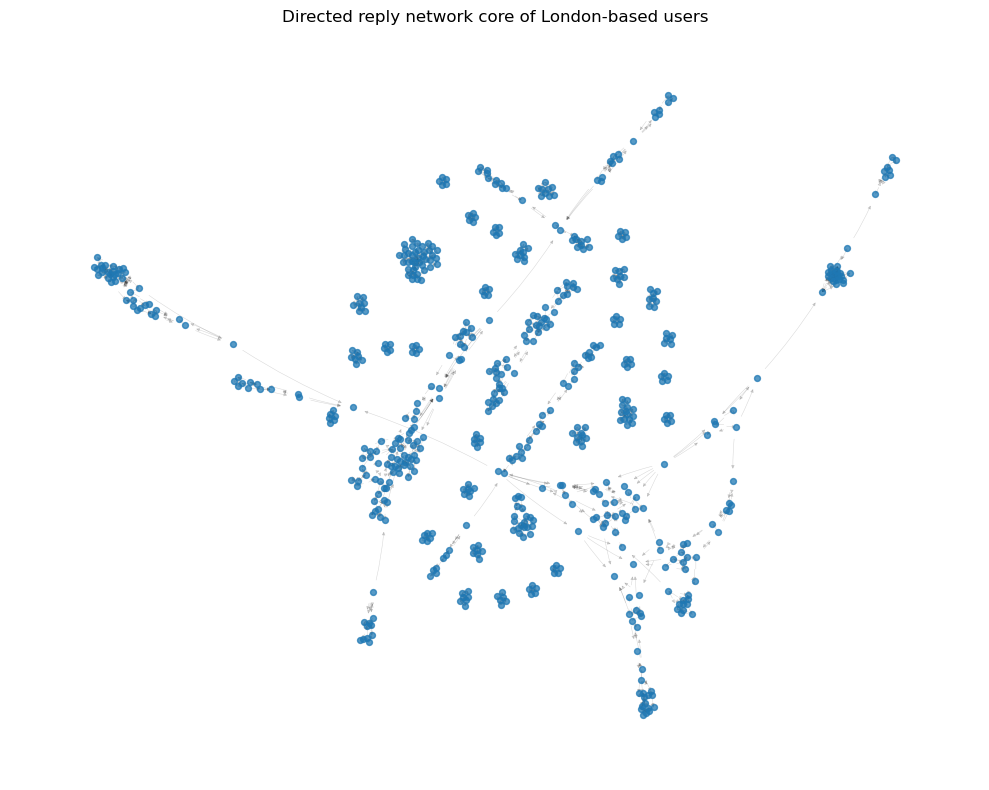

In [81]:
plt.figure(figsize=(10, 8))

reply_pos_adjusted = nx.spring_layout(
    G_reply_core_directed.to_undirected(),
    seed=42,
    k=0.45,
    iterations=200,
    scale=2
)

nx.draw_networkx_edges(
    G_reply_core_directed,
    reply_pos_adjusted,
    arrows=True,
    arrowsize=5,
    alpha=0.15,
    width=0.4,
    connectionstyle="arc3,rad=0.05"
)

nx.draw_networkx_nodes(
    G_reply_core_directed,
    reply_pos_adjusted,
    node_size=18,
    alpha=0.75
)

plt.title("Directed reply network core of London-based users")
plt.axis("off")
plt.tight_layout()
plt.show()

In [82]:
# nodes from the directed reply core
reply_core_nodes = pd.DataFrame({
    "user_id": list(G_reply_core_directed.nodes())
})

reply_core_nodes = reply_core_nodes.merge(
    home_coords,
    on="user_id",
    how="inner"
)

reply_node_gdf = gpd.GeoDataFrame(
    reply_core_nodes,
    geometry=gpd.points_from_xy(
        reply_core_nodes["lon"],
        reply_core_nodes["lat"]
    ),
    crs="EPSG:4326"
)

In [83]:
# edges from the directed reply core
reply_core_edges = nx.to_pandas_edgelist(
    G_reply_core_directed
).rename(columns={
    "source": "source_user",
    "target": "target_user"
})

reply_core_edges_geo = (
    reply_core_edges
    .merge(
        home_coords.rename(columns={
            "user_id": "source_user",
            "lon": "source_lon",
            "lat": "source_lat"
        }),
        on="source_user",
        how="inner"
    )
    .merge(
        home_coords.rename(columns={
            "user_id": "target_user",
            "lon": "target_lon",
            "lat": "target_lat"
        }),
        on="target_user",
        how="inner"
    )
)

reply_edge_gdf = gpd.GeoDataFrame(
    reply_core_edges_geo,
    geometry=[
        LineString([
            (row.source_lon, row.source_lat),
            (row.target_lon, row.target_lat)
        ])
        for row in reply_core_edges_geo.itertuples()
    ],
    crs="EPSG:4326"
)

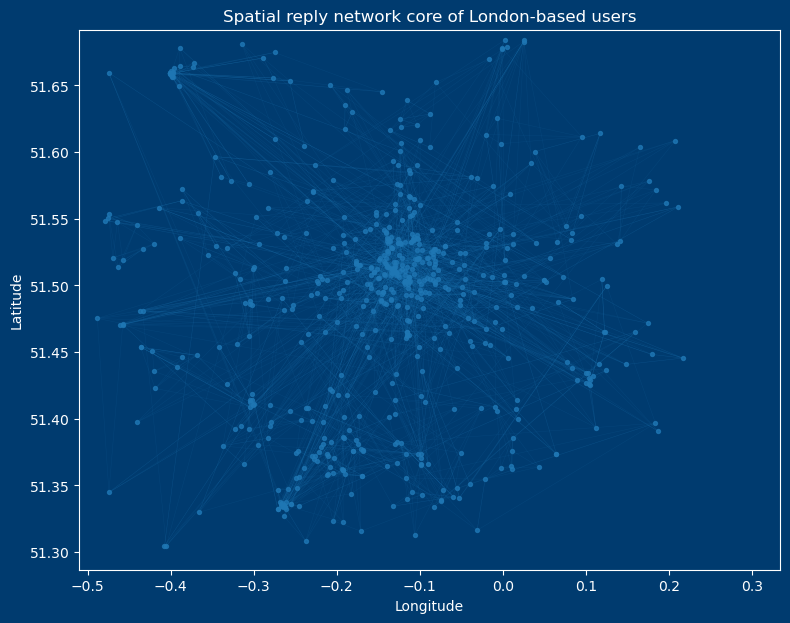

In [84]:
fig, ax = plt.subplots(figsize=(8, 8))

fig.patch.set_facecolor("#003b6f")
ax.set_facecolor("#003b6f")

reply_edge_gdf.plot(
    ax=ax,
    linewidth=0.4,
    alpha=0.15
)

reply_node_gdf.plot(
    ax=ax,
    markersize=8,
    alpha=0.8
)

ax.set_xlim(-0.5103751, 0.3340155)
ax.set_ylim(51.2867601, 51.6918741)

ax.set_title(
    "Spatial reply network core of London-based users",
    color="white"
)

ax.set_xlabel("Longitude", color="white")
ax.set_ylabel("Latitude", color="white")

ax.tick_params(axis="x", colors="white")
ax.tick_params(axis="y", colors="white")

for spine in ax.spines.values():
    spine.set_color("white")

plt.tight_layout()
plt.show()

Spatial reply network core:

- select users from the directed reply network core
- assign each user one observed home-location coordinate from the H3-10 home hexagon
- create point geometries for users
- create line geometries for reply relations between users
- plot the reply network in geographic space
- add an OpenStreetMap basemap for spatial context

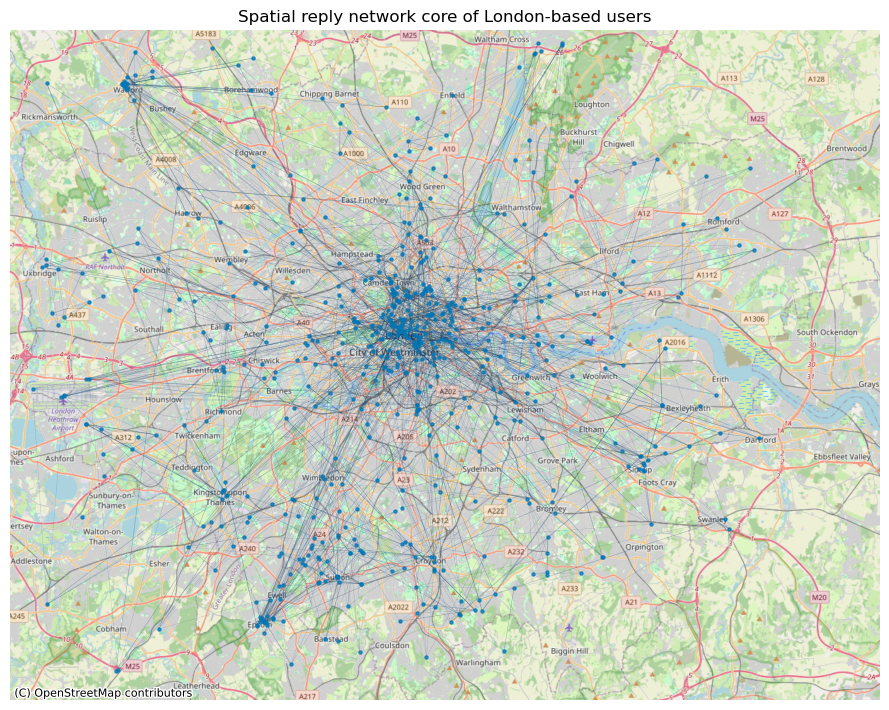

In [85]:
reply_node_gdf_3857 = reply_node_gdf.to_crs(epsg=3857)
reply_edge_gdf_3857 = reply_edge_gdf.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(9, 9))

london_bbox = gpd.GeoDataFrame(
    geometry=[box(-0.5103751, 51.2867601, 0.3340155, 51.6918741)],
    crs="EPSG:4326"
).to_crs(epsg=3857)

xmin, ymin, xmax, ymax = london_bbox.total_bounds
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

ctx.add_basemap(
    ax,
    source=ctx.providers.OpenStreetMap.Mapnik,
    zoom=11
)

reply_edge_gdf_3857.plot(
    ax=ax,
    linewidth=0.35,
    alpha=0.18,
    color="#003b6f",
    zorder=2
)

reply_node_gdf_3857.plot(
    ax=ax,
    markersize=5,
    alpha=0.75,
    color="#0077b6",
    zorder=3
)

ax.set_title("Spatial reply network core of London-based users")
ax.set_axis_off()

plt.tight_layout()
plt.show()